# Module 3.3 — Notebook B: Improve the baseline

In **Notebook A** you evaluated whether Candlekeep’s routing prototype was strong enough for the next MVP step.

Here you take the next step:

> If the baseline is weak, can we improve it in practical ways?

You will try realistic levers: 
- **better prompt design**, 
- **few-shot examples**, 
- an **optional multi-model comparison** with the improved prompt, 
- and **deeper diagnostics**.

The goal is not perfect scores. The goal is to see **what actually helps**, what **trade-offs** appear (cost, latency, safety), and whether the prototype is moving closer to MVP viability.

## What this notebook explores

This notebook focuses on **improvement**, not initial validation.

1. **Prompt refinement** — Can clearer instructions improve routing quality?
2. **Few-shot learning** — Do labeled examples help the model route better?
3. **Trade-offs** — Do improvements change cost or latency?
4. **Diagnostics** — Where does the model still fail, and why?

Assume you have completed Notebook A (or at least have a comparable baseline). You’ll use the **same dataset** and compare every change to that reference.

## Environment

- **Colab / remote:** uncomment the GitHub install line below (restart the runtime if prompted).
- **Local (repo):** uncomment the editable install from the repo root, or ensure `src/` is on `PYTHONPATH`.

Keep your API key in **Secrets** (Colab) or **`.env`** — never commit real keys.

In [1]:
# Colab / remote
# %pip install -q git+https://github.com/mnrozhkov/ai-leader.git

# Local dev (repo root)
%pip install -q -e .

/Users/mnrozhkov/dev/ai-leader/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Configure the improvement experiment

Use the same setup style as Notebook A: one API key, one primary model, and clear defaults.

In this step, you define:
- **candidate models** (for optional comparison later),
- the **baseline prompt** vs **improved prompt**,
- and the **few-shot values** to test.

Keep the first pass simple: one model, deterministic temperature (`0.0`), and fixed monthly volume for cost projection.

This notebook uses async evaluation helpers, so cells that run evaluations use `await`.

In [17]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
from pathlib import Path

from dotenv import load_dotenv

_cwd = Path.cwd().resolve()
ROOT = _cwd if (_cwd / "src" / "ai_leader").is_dir() else _cwd.parent
if (ROOT / "src" / "ai_leader").is_dir() and str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from ai_leader import (  # noqa: E402
    DEFAULT_SYSTEM_PROMPT,
    IMPROVED_SYSTEM_PROMPT,
    Thresholds,
    compute_safety_metrics,
    create_client,
    evaluate_decision,
    evaluate_model_on_dataframe_async,
    generate_prompt_from_mistakes,
    load_and_validate_dataset,
    prepare_mistake_examples,
)
from ai_leader.ablation import (  # noqa: E402
    FewShotAblationConfig,
    prepare_few_shot_ablation_slice,
    run_few_shot_ablation_async,
)
from ai_leader.config import DEFAULT_MAX_CONCURRENCY  # noqa: E402
from ai_leader.reporting import (  # noqa: E402
    display_evaluation_with_department_mistakes,
    display_mvp_decision,
    display_run_comparison_table,
    plot_latency_for_n_shots,
    plot_metrics_for_n_shot,
)

load_dotenv(ROOT / ".env" if (ROOT / ".env").is_file() else ".env", override=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

## Settings

In [15]:
# Colab: paste a key OR rely on os.environ / Secret
api_key = os.getenv("TOKENFACTORY_API_KEY") or os.getenv("OPENAI_API_KEY") or ""
if not api_key:
    api_key = input("Paste TokenFactory API key (or set env): ").strip()

DATASET_URL = os.getenv(
    "AI_LEADER_DATASET_PATH",
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv",
)

# CANDIDATE_MODELS = [
#     "deepseek-ai/DeepSeek-V3.2",
#     "zai-org/GLM-5",
#     "openai/gpt-oss-120b",
# ]

TEMPERATURE = 0.0
MONTHLY_MESSAGES = 20_000

DECISION_THRESHOLDS = Thresholds(
    department_accuracy_pass=0.85,
    category_accuracy_pass=0.85,
    unsafe_auto_route_rate_pass=0.03,
    monthly_cost_usd_pass=1_000.0,
    p95_latency_ms_pass=5_000.0,
)

BASELINE_PROMPT = DEFAULT_SYSTEM_PROMPT
IMPROVED_PROMPT = IMPROVED_SYSTEM_PROMPT

N_SHOT_VALUES = [0, 2, 4, 8, 16]

# Select the best from from Notebook A
MODEL_TO_EVALUATE = "openai/gpt-oss-120b"

# Optional Step 8 — extra API cost
RUN_IMPROVED_MODEL_COMPARE = False

## Step 2 — Load the dataset

Load the **same labeled evaluation dataset** used in Notebook A.

Reusing the same data is important: it makes baseline vs improved comparisons meaningful instead of mixing dataset effects with model/prompt effects.

In [4]:
df = load_and_validate_dataset(DATASET_URL)
print(f"Rows loaded: {len(df)}")
df.head(3)

Rows loaded: 100


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History,row_id
0,My Autumn Oak table arrived with a cracked leg...,Email,True,CK-8821,Order Issue,Returns,2025-10-01 09:12:00,2025-09-24 — Order placed | 2025-09-25 — Shipp...,0
1,I need to change my address for order CK-9902....,Chat,True,CK-9902,Delivery,Logistics,2025-09-19 14:00:00,2025-09-12 — Order placed | 2025-09-14 — Shipp...,1
2,Where is my package? The tracking says DPD has...,Social,True,CK-1102,Delivery,Logistics,2025-10-01 10:15:00,2025-09-24 — Order placed | 2025-09-26 — Shipp...,2


**Optional:** department distribution in gold labels.

In [5]:
df["Routing to Department"].value_counts()

Routing to Department
Logistics           29
Customer Support    27
Product Team        23
Returns             21
Name: count, dtype: int64

## Step 3 — Baseline reference run

Create a client and run the **baseline prompt** on the full evaluation frame.

This run is your reference point. Every change later (prompt rewrite, few-shot examples, optional model comparison) should be interpreted against this baseline.

In [6]:
client = create_client(api_key, model=MODEL_TO_EVALUATE)

baseline_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=BASELINE_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
    use_progress=True,
)

Output()

Confirm **misroute rate**, **department accuracy**, **safety**, **cost**, and **latency** before changing anything.

In [7]:
baseline_sm = compute_safety_metrics(df, baseline_run.predictions)

baseline_decision = evaluate_decision(
    quality_metrics=baseline_run.quality_metrics,
    safety_metrics=baseline_sm,
    cost_metrics=baseline_run.cost_metrics,
    latency_metrics=baseline_run.latency_metrics,
    thresholds=DECISION_THRESHOLDS,
)

display_mvp_decision(decision=baseline_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.610,0.85
1,Category Accuracy,fail,0.620,0.85
2,Unsafe Auto Route Rate,fail,0.350,0.03
3,Monthly Cost Usd,pass,3.394,1000.00
4,P95 Latency Ms,pass,2517.149,5000.00


**Recommendation:** `Improve and re-test (failing: department_accuracy, category_accuracy, unsafe_auto_route_rate)`

## Step 4 — Try improved prompt


In [ ]:
improved_prompt_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=IMPROVED_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
)

Output()

In [21]:
improved_prompt_sm = compute_safety_metrics(df, improved_prompt_run.predictions)

improved_prompt_decision = evaluate_decision(
    quality_metrics=improved_prompt_run.quality_metrics,
    safety_metrics=improved_prompt_sm,
    cost_metrics=improved_prompt_run.cost_metrics,
    latency_metrics=improved_prompt_run.latency_metrics,
    thresholds=DECISION_THRESHOLDS,
)

display_mvp_decision(decision=improved_prompt_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.710,0.85
1,Category Accuracy,fail,0.840,0.85
2,Unsafe Auto Route Rate,fail,0.260,0.03
3,Monthly Cost Usd,pass,4.712,1000.00
4,P95 Latency Ms,pass,3993.290,5000.00


**Recommendation:** `Improve and re-test (failing: department_accuracy, category_accuracy, unsafe_auto_route_rate)`

## Step 4 — Improve prompt from mistakes

Collect mistake examples from the baseline run, inspect a few concrete failures,
and ask the model to rewrite the routing prompt using those errors as guidance.

In [22]:
mistake_examples = await prepare_mistake_examples(
    eval_df=df,
    predictions=improved_prompt_run.predictions,
    max_per_type=3,
)

display(mistake_examples.head(3))

UPDATED_PROMPT_FROM_MISTAKES = await generate_prompt_from_mistakes(
    current_prompt=IMPROVED_PROMPT,
    mistake_examples=mistake_examples,
    client=client,
    model=MODEL_TO_EVALUATE,
)
print(UPDATED_PROMPT_FROM_MISTAKES)

,type,request_text,gold_category,predicted_category,gold_department,predicted_department
0,category,Website is crashing on the payment screen.,General Feedback,Payment,Product Team,Customer Support
1,category,I am going to sue your company if you don't fi...,Delivery,Order Issue,Logistics,Returns
2,category,Refund the holiday wreath. It looks cheap.,Order Issue,Payment,Returns,Customer Support


You are the AI routing assistant for Candlekeep, an e-commerce company that receives 10,000+ customer messages per month across email, chat, phone, and social channels.

**Your task:** Read each incoming customer message, determine the most appropriate *Category* and the *Department* that should handle it, generate a brief initial response for the assigned agent, and assign a confidence level.

### Categories (choose ONE that best matches the primary request)
- **Payment** – questions or actions about refunds, charges, billing disputes, payment‑method updates, or any monetary transaction.
- **Order Issue** – problems with the physical product itself: damaged items, missing parts, wrong items, exchanges, returns, safety hazards, or missing instructions.
- **Delivery** – anything about shipping: delays, tracking, address changes, delivery‑window complaints, or logistics‑related problems.
- **General Feedback** – product praise or complaints, feature requests, bulk‑order pricing inquiries

In [ ]:
mistake_refined_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=UPDATED_PROMPT_FROM_MISTAKES,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
)

Output()

In [25]:
_ = display_run_comparison_table(
    baseline=improved_prompt_run,
    new=mistake_refined_run,
    eval_df=df,
    new_label="Prompt updated from mistakes",
    show_all=False,
)

,baseline,Prompt updated from mistakes,delta_vs_baseline
department_accuracy,0.71,0.78,0.070
category_accuracy,0.84,0.89,0.050
unsafe_auto_route_rate,0.26,0.21,-0.050
monthly_cost_usd,4.712,4.555,-0.157
p95_latency_ms,3993.29,2492.754,-1500.536


In [27]:
mistake_refined_sm = compute_safety_metrics(df, mistake_refined_run.predictions)

mistake_refined_decision = evaluate_decision(
    quality_metrics=mistake_refined_run.quality_metrics,
    safety_metrics=mistake_refined_sm,
    cost_metrics=mistake_refined_run.cost_metrics,
    latency_metrics=mistake_refined_run.latency_metrics,
    thresholds=DECISION_THRESHOLDS,
)

display_mvp_decision(decision=mistake_refined_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.780,0.85
1,Category Accuracy,pass,0.890,0.85
2,Unsafe Auto Route Rate,fail,0.210,0.03
3,Monthly Cost Usd,pass,4.555,1000.00
4,P95 Latency Ms,pass,2492.754,5000.00


**Recommendation:** `Improve and re-test (failing: department_accuracy, unsafe_auto_route_rate)`

## Step 5 — Alternative improvement path: few-shot trade-offs

So far, you improved routing with an **LLM-generated prompt**.  
In this step, you test a different lever: **few-shot examples**.

The goal is to see whether adding labeled examples improves quality compared to the **same baseline run**, and what trade-offs appear in cost and latency.


Read this chart as:
- quality gain vs baseline,
- cost increase vs baseline,
- latency change vs baseline,
- and where returns start to flatten as `n_shot` grows.

In [11]:
ablation_config = FewShotAblationConfig(
    best_model=MODEL_TO_EVALUATE,
    few_shot_counts=N_SHOT_VALUES,
    ablation_random_state=42,
    few_shot_pool_n=32,
    ablation_eval_n=68,
)

few_shot_pool_df, eval_df_fixed, few_shot_counts = prepare_few_shot_ablation_slice(
    df,
    config=ablation_config,
)

ablation_df, _phase2_predictions = await run_few_shot_ablation_async(
    few_shot_pool_df=few_shot_pool_df,
    eval_df_fixed=eval_df_fixed,
    few_shot_counts=few_shot_counts,
    best_model=MODEL_TO_EVALUATE,
    client=client,
    max_concurrency=DEFAULT_MAX_CONCURRENCY,
    system_prompt=DEFAULT_SYSTEM_PROMPT,  # Use a prompt from the previous step
    temperature=TEMPERATURE,
    show_progress=True,
)

ablation_default_columns = [
    "n_shot",
    "department_accuracy",
    "category_accuracy",
    "cost_total_usd",
    "p95_latency_ms",
]
display(ablation_df[[c for c in ablation_default_columns if c in ablation_df.columns]])

Output()

Few-shot ablation slice: pool=32 rows, fixed eval=68 rows, model=openai/gpt-oss-120b


Output()

Output()

Output()

Output()

,n_shot,department_accuracy,category_accuracy,cost_total_usd,p95_latency_ms
0,0,0.573529,0.676471,0.011516,2657.884019
1,2,0.661765,0.720588,0.013093,2920.156573
2,4,0.617647,0.794118,0.013181,3233.202583
3,8,0.808824,0.882353,0.015380,2592.699415
4,16,0.808824,0.926471,0.023459,2729.183384


## Step 6 — Visualize few-shot trade-offs

Accuracy vs `n_shot`, cost, and latency. Interpret: where do gains **flatten**?

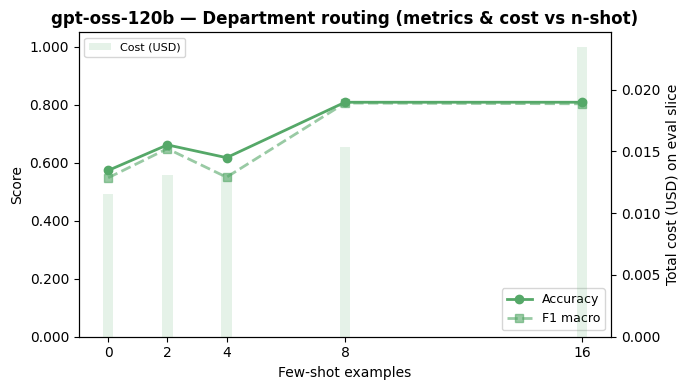

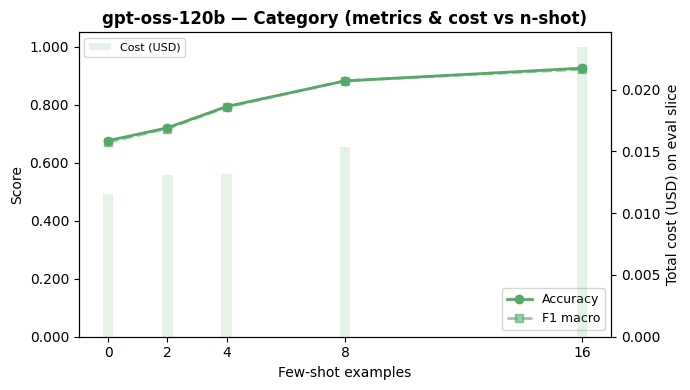

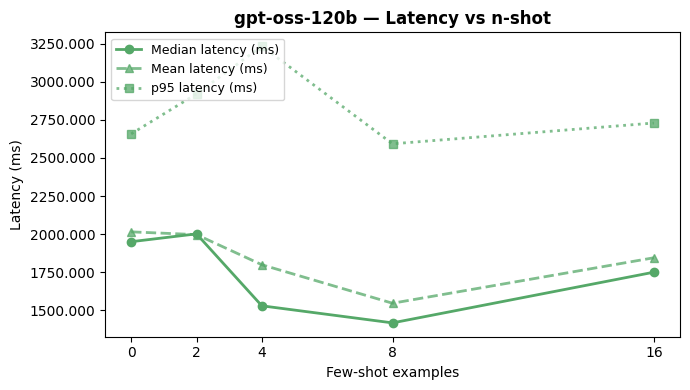

In [12]:
_ = plot_metrics_for_n_shot(ablation_df, best_model=MODEL_TO_EVALUATE)
_ = plot_latency_for_n_shots(ablation_df, best_model=MODEL_TO_EVALUATE)

## Step 7 — Deeper analysis

This step answers the most useful follow-up question: **why are errors still happening?**

Use `display_evaluation_results` to inspect confusion and confidence patterns, then look at a few concrete mistakes.

The goal is to identify repeatable failure modes (for example, specific department confusions), not just a single aggregate score.

category_accuracy           0.890
category_f1_macro           0.887
department_accuracy         0.780
department_f1_macro         0.778
exact_route_match_rate      0.760
misroute_rate               0.220
row_count                 100.000


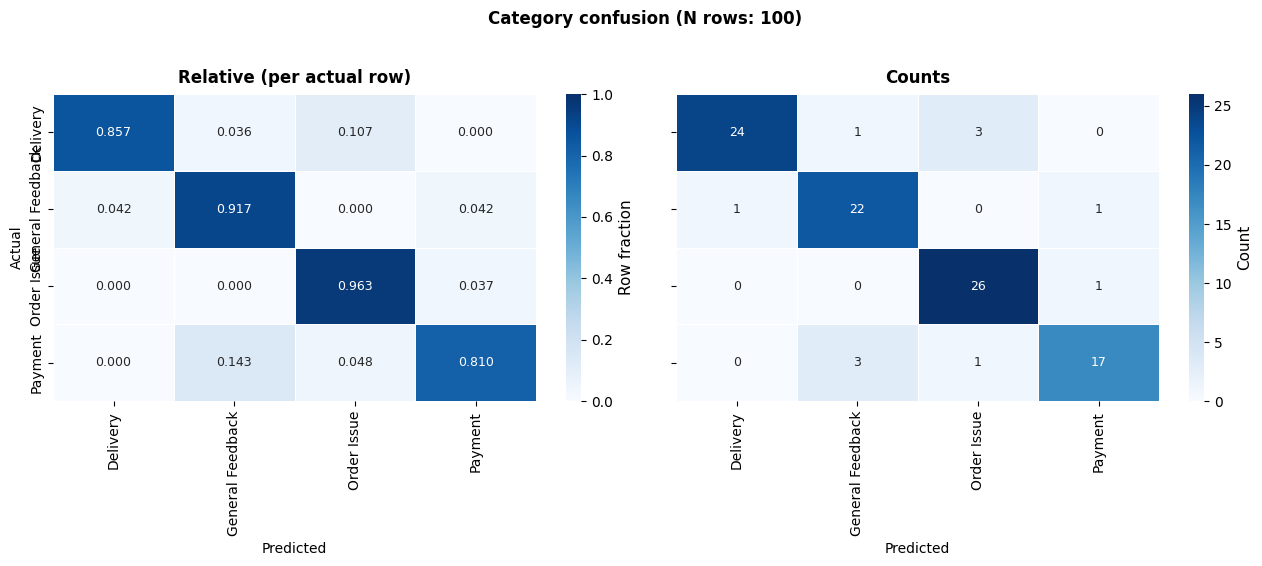

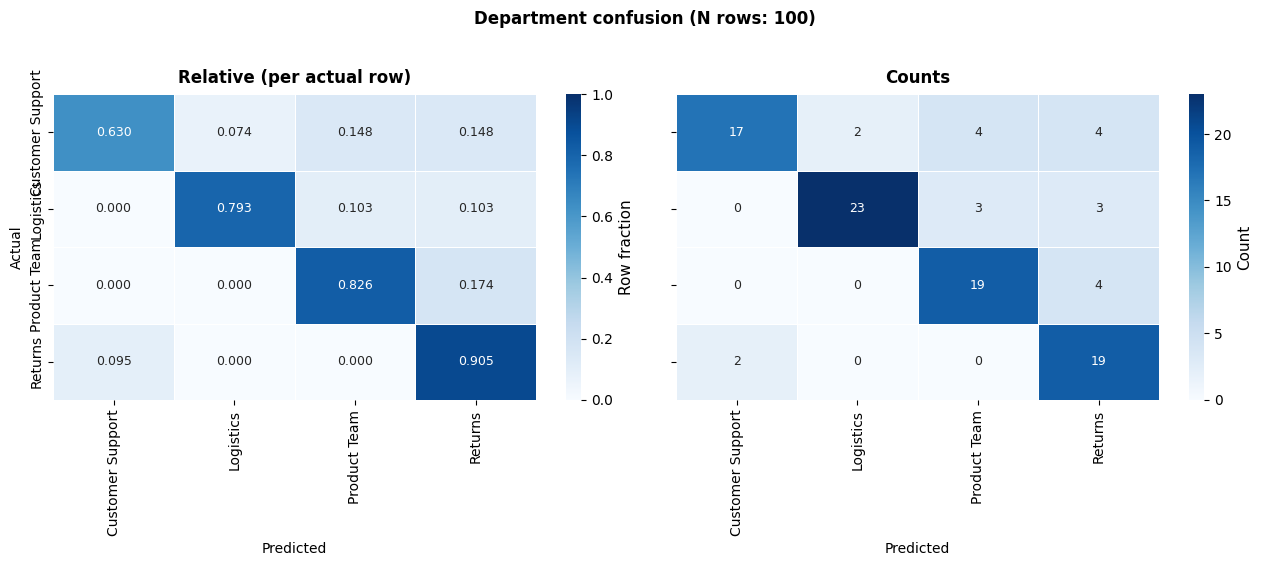

,Request Text,Routing to Department,predicted_department
4,The toaster oven sparked when I plugged it in....,Product Team,Returns
8,Instructions for the Lumina lamp are missing f...,Product Team,Returns
19,I am going to sue your company if you don't fi...,Logistics,Returns
26,Package in rain rug ruined.,Logistics,Returns
29,Talk to manager now. Support is useless.,Logistics,Product Team
32,No refund received for return CK-9944.,Returns,Customer Support
35,Order canceled without my permission.,Customer Support,Returns
37,Add one more lamp to order CK-1100.,Customer Support,Returns
40,Received two lamps only ordered one.,Customer Support,Returns
42,Discount for military?,Customer Support,Product Team


In [29]:
mistakes = display_evaluation_with_department_mistakes(
    eval_results=mistake_refined_run,
    eval_df=df,
    max_rows=10,
)
mistakes

## Summary

This notebook evaluates multiple improvement approaches against the same baseline workflow so changes are attributable to the method, not to different data.

Approaches covered:
- **Prompt refinement from mistakes**: extract representative routing errors, revise instructions, and re-evaluate.
- **Few-shot ablation**: vary the number of examples to measure quality gains versus cost/latency overhead.
- **Diagnostic review**: inspect confusion patterns and concrete misroutes to understand residual failure modes.

Result pattern to report (without fixed numbers):
- Routing quality typically improves from baseline after targeted prompt changes.
- Safety may improve, stay flat, or regress depending on confidence behavior; verify before rollout.
- Cost and latency usually increase as prompts/examples become richer.
- Best choice is the configuration with the strongest quality and safety improvement for acceptable cost/speed trade-offs.

Use this section as a run-agnostic narrative of *what was tried* and *what direction the metrics moved*.


---

*Disclaimer: This notebook is for learning and offline evaluation. Results depend on dataset scope, prompt choices, and model version/availability; validate with fresh runs before production decisions. Instructor artifacts (predictions CSV, summary JSON, plots) may be generated by separate tooling and are not required for this student-facing flow.*